## Title

#### 📊 Customer Churn Analysis

### Objective
Analyze customer data to identify key factors driving churn and provide actionable business insights.

### Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### Data Cleaning

### Load Dataset

In [49]:
from google.colab import files
uploaded = files.upload()

Telco = pd.read_csv("Telco-Customer-Churn.csv")
Telco.head()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (4).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- The dataset initially showed no missing values.
- However, after converting `TotalCharges` to numeric, 11 missing values were identified.
- These rows were removed as they represent a very small portion of the dataset (~0.15%).
- Final dataset is clean and ready for analysis.

### Shape and Duplicate Check

In [50]:
print("Shape:", Telco.shape)

print("Duplicate Rows:", Telco.duplicated().sum())

Shape: (7043, 21)
Duplicate Rows: 0


In [51]:
Telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
Telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Detect Hidden Missing Values

In [53]:
(Telco['TotalCharges'] == " ").sum()

np.int64(11)

In [54]:
Telco['TotalCharges'] = pd.to_numeric(Telco['TotalCharges'], errors='coerce')

In [55]:
Telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [56]:
Telco = Telco.dropna()

In [57]:
Telco.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Exploratory Data Analysis

#### Churn Distribution

### Question 1: What is the overall churn rate?

In [58]:
Telco['Churn'].value_counts()
Telco['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


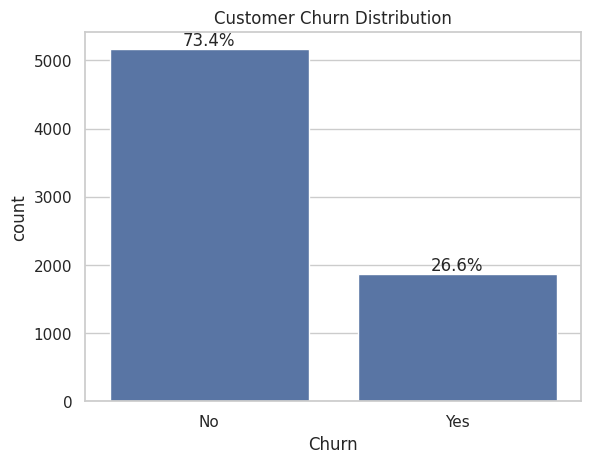

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='Churn', data=Telco)

for p in ax.patches:
    percentage = f'{100 * p.get_height()/len(Telco):.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Customer Churn Distribution")
plt.show()

## Insight

### 🔍 Churn Distribution
- Approximately 26–27% of customers have churned.
- This indicates a significant retention problem.
- Majority of customers are retained, but churn is still high enough to impact revenue.

### Question 2: Does contract type affect churn?

In [68]:
contract_churn = pd.crosstab(
    Telco['Contract'],
    Telco['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


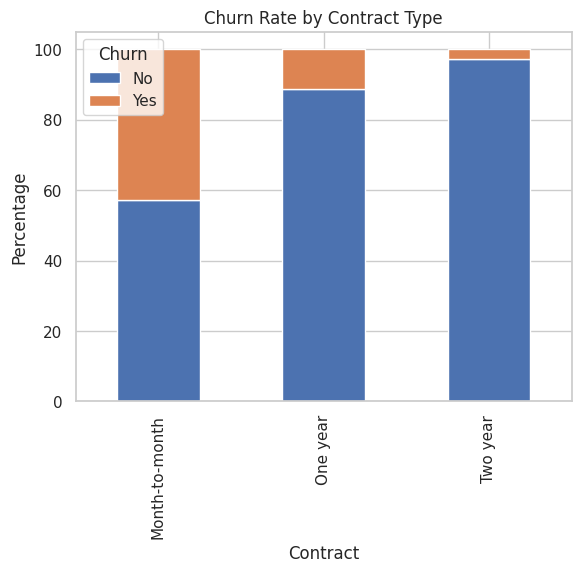

In [69]:
contract_churn.plot(kind='bar', stacked=True)
plt.ylabel("Percentage")
plt.title("Churn Rate by Contract Type")
plt.show()

## Insight

### 🔍 Contract Type vs Churn

- Customers with **month-to-month contracts** have the highest churn rate.
- Customers with **one-year and two-year contracts** are significantly more stable.
- Lack of long-term commitment increases churn risk.

### 📌 Business Insight
Encourage customers to shift to long-term contracts through discounts or benefits.

## Question 3: Do monthly charges influence churn?

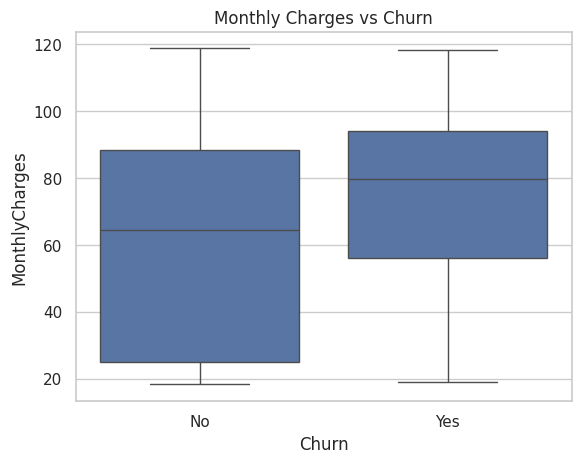

In [61]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=Telco)
plt.title("Monthly Charges vs Churn")
plt.show()

### 🔍 Monthly Charges vs Churn

- Customers with higher monthly charges tend to churn more.
- Pricing may be a key factor influencing customer decisions.

### 📌 Business Insight
Consider pricing optimization or bundling services for high-paying customers.

### Question 4: Does customer tenure affect churn behavior?

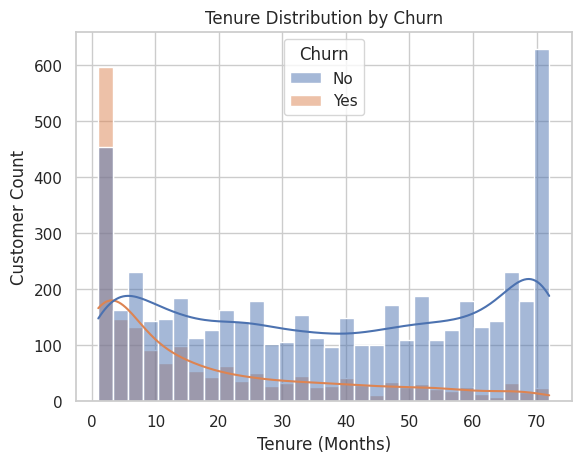

In [62]:
sns.histplot(data=Telco, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Count")
plt.show()

### 🔍 Tenure vs Churn Insight

- Customers with lower tenure are more likely to churn.
- Long-term customers show significantly lower churn rates.
- Most churn occurs during the early months of customer engagement.

### 📌 Business Insight

- Improve onboarding experience for new customers.
- Provide loyalty benefits during the first 6–12 months.
- Create retention campaigns targeting recently joined customers.

### Question 4: Which internet service category has the highest churn rate?

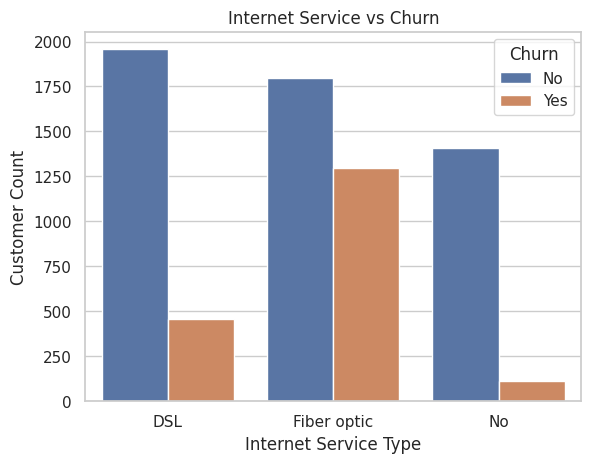

In [63]:
sns.countplot(x='InternetService', hue='Churn', data=Telco)
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service Type")
plt.ylabel("Customer Count")
plt.show()

### 🔍 Internet Service vs Churn Insight

- Customers using Fiber Optic internet have the highest churn rate.
- DSL customers are comparatively more stable.
- Fiber Optic customers may be experiencing service quality or pricing concerns.

### 📌 Business Insight

- Investigate customer complaints related to Fiber Optic service.
- Improve service reliability and customer support.
- Offer retention discounts for Fiber Optic users.

### Question 5: Which telecom services are associated with higher customer churn?

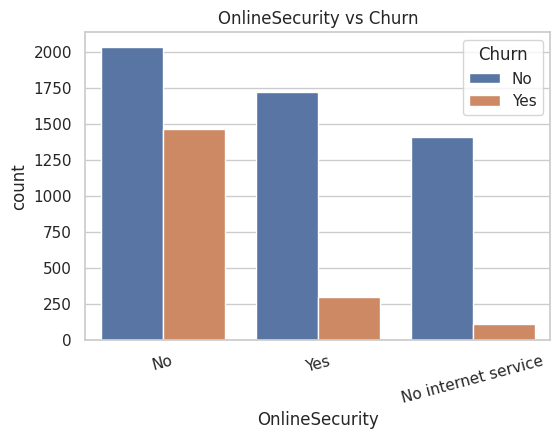

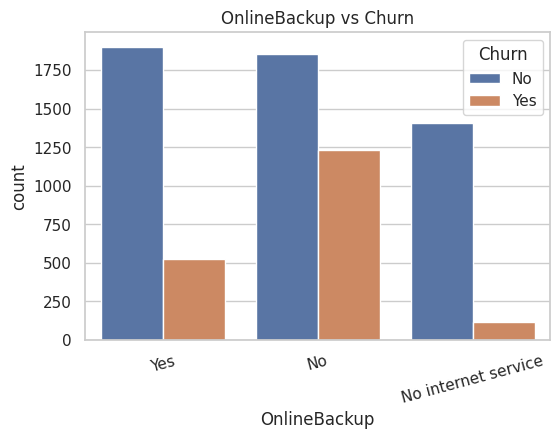

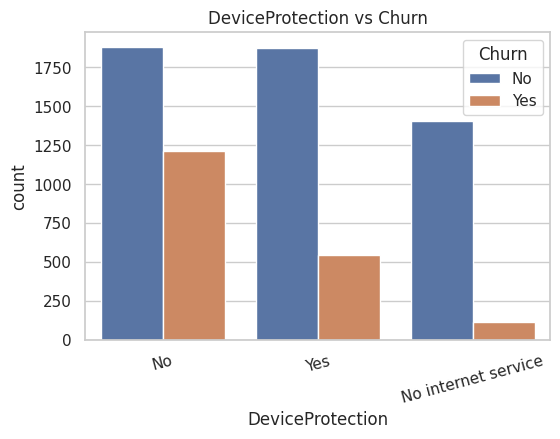

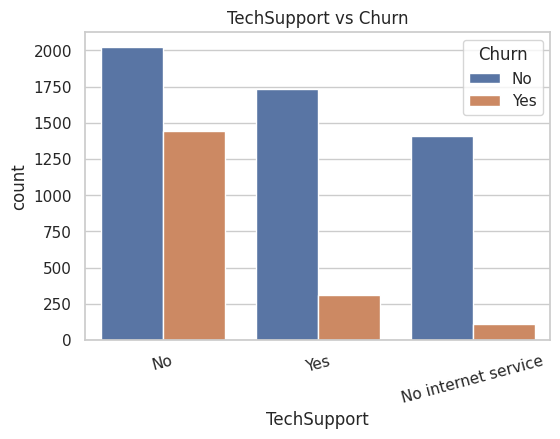

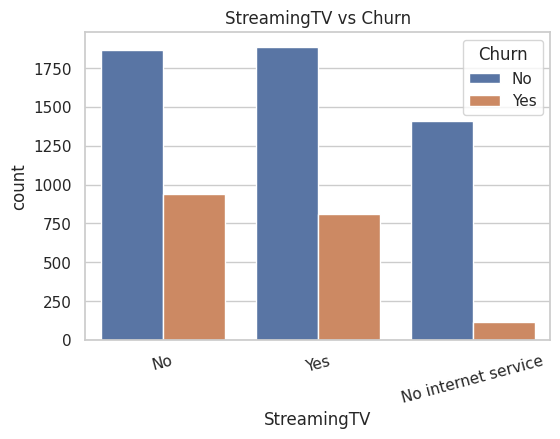

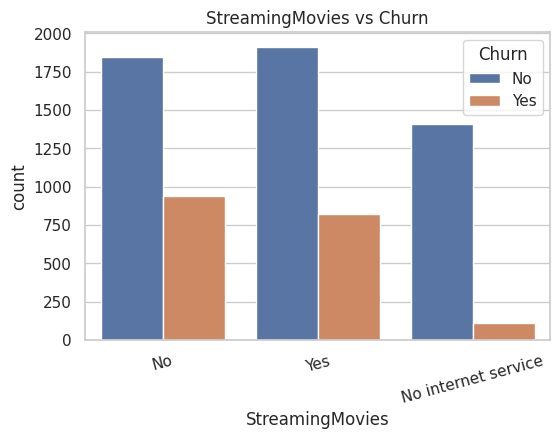

In [64]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

for service in services:
    plt.figure(figsize=(6,4))
    sns.countplot(x=service, hue='Churn', data=Telco)
    plt.title(f"{service} vs Churn")
    plt.xticks(rotation=15)
    plt.show()

### 🔍 Service Analysis Insight

- Customers without Online Security and Tech Support show significantly higher churn.
- Streaming services have a moderate relationship with churn.
- Security and support-related services appear to improve customer retention.

### 📌 Business Insight

- Promote bundled plans including Online Security and Tech Support.
- Educate customers about the value of support and protection services.
- Offer free trials for support-related services to reduce churn risk.

### Question 6: Are senior citizens more likely to churn?

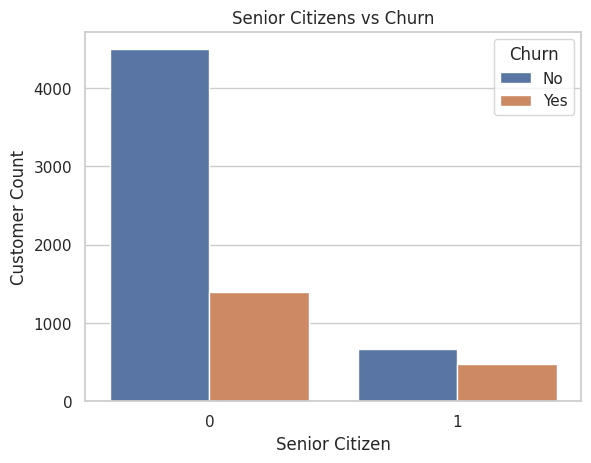

In [65]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=Telco)
plt.title("Senior Citizens vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Customer Count")
plt.show()

### 🔍 Senior Citizen vs Churn Insight

- Senior citizens show a relatively higher churn rate compared to non-senior customers.
- Older customers may require better support and service accessibility.

### 📌 Business Insight

- Provide dedicated support for senior customers.
- Simplify service plans and billing processes.
- Improve customer assistance and communication channels.

### Question 7: Which numerical variables show correlation patterns in the dataset?

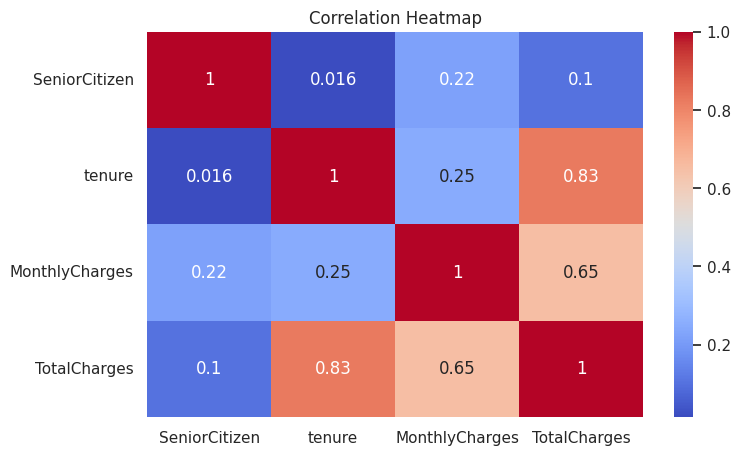

In [66]:
plt.figure(figsize=(8,5))

sns.heatmap(Telco.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### 🔍 Correlation Heatmap Insight

- Tenure and Total Charges show strong positive correlation.
- Customers with longer tenure naturally generate higher total charges.
- Monthly Charges show moderate correlation with Total Charges.
- No extremely strong correlation exists among most variables.

### 📌 Business Insight

- Focus on improving long-term customer retention.
- Increasing customer tenure can significantly improve customer lifetime value.
- Use tenure-based loyalty programs to maximize revenue.

### Conclusion

This analysis identified key factors contributing to customer churn, including:
- Contract type
- Monthly charges
- Tenure
- Internet service type
- Support-related services

The findings can help telecom companies improve customer retention strategies and reduce churn-related revenue loss.

## 📌 Final Business Summary

This analysis revealed that customer churn is primarily influenced by:

- Month-to-month contracts
- High monthly charges
- Low customer tenure
- Lack of support/security services
- Fiber optic internet users

The company can reduce churn by:
- Promoting long-term plans
- Improving onboarding
- Enhancing support services
- Optimizing pricing strategies